# Part 3: Modeling
Having visualized the data, we will now initiate our machine learning model.<br>
The Random Forest is an appropriate model for this sort of data.  First, we will split the data for test/train (classic 80/20 split).<br>
After performing the split, we will take a look at the model's statistics and visualize the accuracy in a graph.<br>
We will follow by performing the same model on a 5-fold GroupKFold (split by transition metal) and compare to the base RF model.<br>

In [39]:
#Split train and test similar to week 5
# Cell A3 — Separate feature matrix X and target vector y
# LECTURE DEMO

from sklearn.model_selection import train_test_split

X_magpie = mat_df[magpie_cols].copy()
y_mag = mat_df["Magnetization per Atom (µB/atom)"].copy()

print(f'X shape: {X_magpie.shape}  (samples \u00d7 features)')
print(f'y shape: {y_mag.shape}')
print(f'\ny (mag_per_atom) summary:')
print(y_mag.describe().round(3))

X shape: (816, 132)  (samples × features)
y shape: (816,)

y (mag_per_atom) summary:
count    816.000
mean       0.233
std        0.410
min        0.000
25%        0.000
50%        0.000
75%        0.318
max        3.100
Name: Magnetization per Atom (µB/atom), dtype: float64


In [40]:
#I debated doing a stratify by magnetic/non-magnetic here but ultimately the proportions are even enough that it shouldn't be a problem (we will do a different strategy later anyways)
X_magpie_train, X_magpie_test, y_mag_train, y_mag_test = train_test_split(
    X_magpie, y_mag,
    test_size=0.2,
    random_state=42
)

print(f'Train: {len(X_magpie_train):,} samples')
print(f'Test:  {len(X_magpie_test):,} samples')
print(f'\nTrain y mean: {y_mag_train.mean():.3f} µB  Test y mean: {y_mag_test.mean():.3f} µB')
print(f'Train y std:  {y_mag_train.std():.3f} µB  Test y std:  {y_mag_test.std():.3f} µB\n')

Train: 652 samples
Test:  164 samples

Train y mean: 0.245 µB  Test y mean: 0.186 µB
Train y std:  0.428 µB  Test y std:  0.327 µB



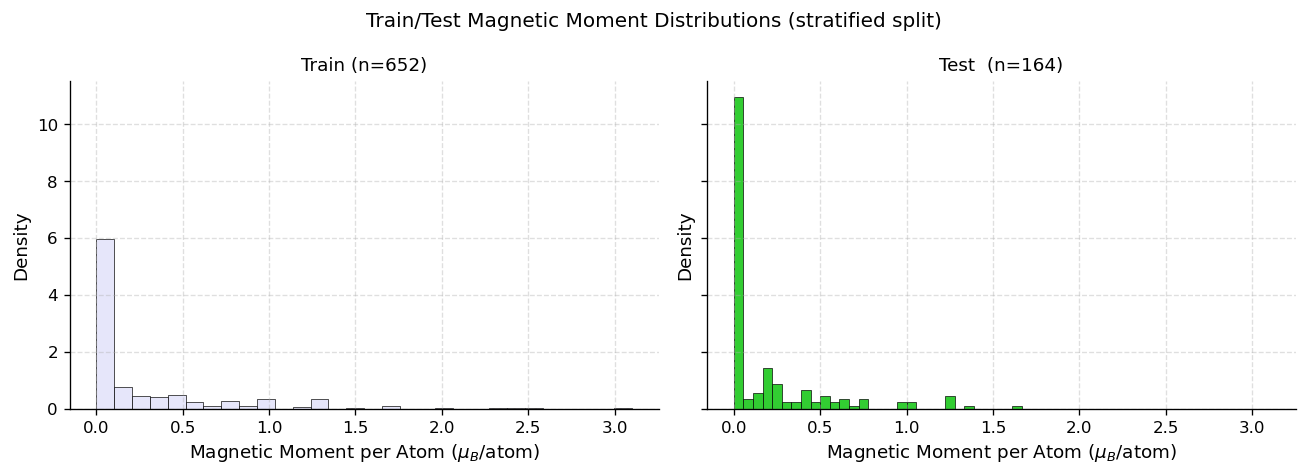

In [41]:
#Now you plot it again (like above)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

for ax, data, label, color, in [
    (axes[0], y_mag_train, f'Train (n={len(y_mag_train):,})', 'lavender'),
    (axes[1], y_mag_test,  f'Test  (n={len(y_mag_test):,})',  'limegreen'),
]:
    ax.hist(data, bins=30, color=color,
            density=True, edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Magnetic Moment per Atom ($\mu_B$/atom)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(label, fontsize=11)

plt.suptitle('Train/Test Magnetic Moment Distributions (stratified split)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '03_train_test_magmom_distribution'), dpi=150, bbox_inches='tight')
plt.show()

In [42]:
#Now do the random forest (COPY FROM WEEK 5)

#The ratio between magnetic/non-magnetic is roughly 41:59- so class weighting is not going to be necessary here
rf = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_magpie_train, y_mag_train)
y_mag_pred_rf = rf.predict(X_magpie_test)

mae_rf  = mean_absolute_error(y_mag_test, y_mag_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_mag_test, y_mag_pred_rf))
r2_rf   = r2_score(y_mag_test, y_mag_pred_rf)

print('Random Forest (n_estimators=100):')
print(f'  MAE:  {mae_rf:.3f} µB/atom')
print(f'  RMSE: {rmse_rf:.3f} µB/atom')
print(f'  R\u00b2:   {r2_rf:.3f}\n')
print(f"From the RF regression, we get low MAE and RMSE, along with a reasonably high R^2- this model is a good one.")

Random Forest (n_estimators=100):
  MAE:  0.071 µB/atom
  RMSE: 0.133 µB/atom
  R²:   0.833

From the RF regression, we get low MAE and RMSE, along with a reasonably high R^2- this model is a good one.


In [43]:
#GroupKFold w/5 bins by transition metal- will implement this.  No idea how to do it, so Gemini helped me
import re
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor

# Re-use your transition metals list from earlier cells
transition_metals = [
    "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn",
    "Y", "Zr", "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd",
    "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg"
]

#Gemini helped me with this function to match the transition metal in the chemical formula string
def get_transition_metal(formula):
    for tm in transition_metals:
        if formula.startswith(tm):
            return tm
    return "Unknown"

mat_df['tm_group'] = mat_df['Formula'].apply(get_transition_metal)
groups = mat_df['tm_group'].values

gkf = GroupKFold(n_splits=5)

#For storing metrics
fold_mae, fold_rmse, fold_r2 = [], [], []

print(f"=== Running 5-Fold GroupKFold Cross-Validation ===")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_magpie, y_mag, groups=groups)):
    X_magpie_train_fold, X_magpie_test_fold = X_magpie.iloc[train_idx], X_magpie.iloc[test_idx]
    y_mag_train_fold, y_mag_test_fold = y_mag.iloc[train_idx], y_mag.iloc[test_idx]
    #Verifying that we have the correct metals in train/test (Gemini helped)
    train_metals = mat_df['tm_group'].iloc[train_idx].unique()
    test_metals = mat_df['tm_group'].iloc[test_idx].unique()
    
    rf.fit(X_magpie_train_fold, y_mag_train_fold)
    y_mag_pred_fold = rf.predict(X_magpie_test_fold)
    
    #Statistics for each fold
    mae_kfold = mean_absolute_error(y_mag_test_fold, y_mag_pred_fold)
    rmse_kfold = np.sqrt(mean_squared_error(y_mag_test_fold, y_mag_pred_fold))
    r2_kfold = r2_score(y_mag_test_fold, y_mag_pred_fold)
    fold_mae.append(mae_kfold)
    fold_rmse.append(rmse_kfold)
    fold_r2.append(r2_kfold)
    
    print(f"Fold {fold+1}: MAE = {mae_kfold:.3f} | RMSE = {rmse_kfold:.3f} | R² = {r2_kfold:.3f}")
    print(f"        Test Metals ({len(test_metals)}): {list(test_metals)}")

#Output for performance
print("\n=== Overall Cross-Validation Performance ===")
print(f"Mean MAE:  {np.mean(fold_mae):.3f} ± {np.std(fold_mae):.3f} µB/atom")
print(f"Mean RMSE: {np.mean(fold_rmse):.3f} ± {np.std(fold_rmse):.3f} µB/atom")
print(f"Mean R²:   {np.mean(fold_r2):.3f} ± {np.std(fold_r2):.3f}\n")
print(f"GroupKFold lowers the R^2 significantly due to binning by metal- but it is necessary to avoid data leakage.")

=== Running 5-Fold GroupKFold Cross-Validation ===
Fold 1: MAE = 0.045 | RMSE = 0.103 | R² = 0.475
        Test Metals (3): ['Cd', 'Rh', 'Tc']
Fold 2: MAE = 0.189 | RMSE = 0.248 | R² = 0.215
        Test Metals (6): ['Nb', 'Os', 'Ta', 'Pd', 'Ru', 'V']
Fold 3: MAE = 0.215 | RMSE = 0.257 | R² = 0.323
        Test Metals (7): ['Cu', 'Mo', 'Y', 'Hf', 'Co', 'Sc', 'Hg']
Fold 4: MAE = 0.216 | RMSE = 0.376 | R² = 0.521
        Test Metals (7): ['Ni', 'Zn', 'Pt', 'W', 'Ag', 'Lu', 'Mn']
Fold 5: MAE = 0.242 | RMSE = 0.362 | R² = 0.517
        Test Metals (7): ['Zr', 'Ir', 'Re', 'Cr', 'Fe', 'Ti', 'Au']

=== Overall Cross-Validation Performance ===
Mean MAE:  0.181 ± 0.070 µB/atom
Mean RMSE: 0.269 ± 0.098 µB/atom
Mean R²:   0.410 ± 0.122

GroupKFold lowers the R^2 significantly due to binning by metal- but it is necessary to avoid data leakage.
